
学習則ごとの全体平均正答率と標準偏差
  rule  n  accuracy8_mean  accuracy8_std  accuracy3_mean  accuracy3_std
  STDP 10        0.475375       0.033484        0.743375       0.024267
T_STDP 10        0.557250       0.045776        0.786875       0.027210
  SRDP 10        0.666250       0.033850        0.843500       0.016789

--- 平均 ± 標準偏差 ---
STDP: 8cls = 0.4754 ± 0.0335, 3cls = 0.7434 ± 0.0243 (n=10)
T_STDP: 8cls = 0.5573 ± 0.0458, 3cls = 0.7869 ± 0.0272 (n=10)
SRDP: 8cls = 0.6663 ± 0.0339, 3cls = 0.8435 ± 0.0168 (n=10)
EXCEL_ROOT     : C:\Users\haru4\研究\研究コード\code\results_10fold
OUT_DIR        : C:\Users\haru4\研究\研究コード\code\analysis\analysi.ipynb
Rows(Tn)       : 30
AvailableRules : ['SRDP', 'STDP', 'T_STDP', 'off']
SelectedRules  : ['STDP', 'T_STDP', 'SRDP']
[SAVED] c:\Users\haru4\研究\研究コード\code\analysis\analysi.ipynb\boxplot_8cls_Tn25_STDP_T_STDP_SRDP.pdf


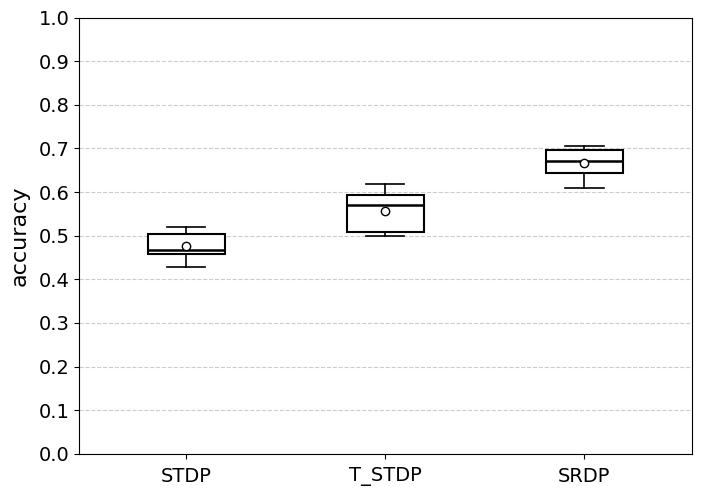

[SAVED] c:\Users\haru4\研究\研究コード\code\analysis\analysi.ipynb\boxplot_3cls_Tn25_STDP_T_STDP_SRDP.pdf


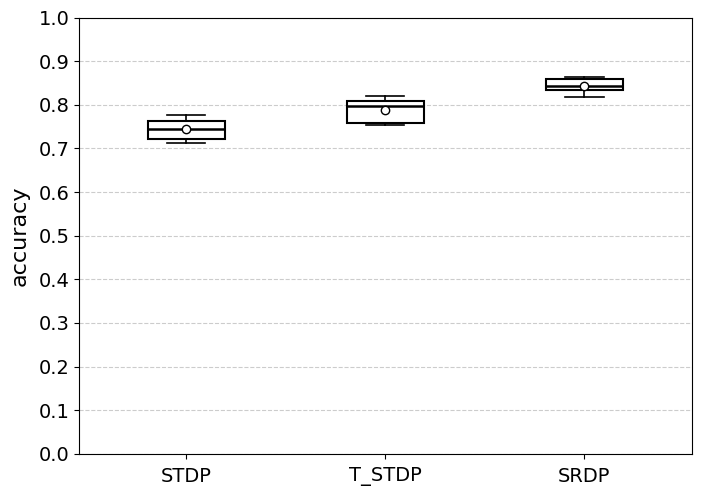


--- repごとの値 ---
  rule  rep  accuracy8_mean  accuracy3_mean                                                                                                file
  SRDP    1         0.65250         0.82125     C:\Users\haru4\研究\研究コード\code\results_10fold\SRDP_1\SRDP_1_rep01_Tn_25_10fold_conf_matrices.xlsx
  SRDP    2         0.67125         0.83875     C:\Users\haru4\研究\研究コード\code\results_10fold\SRDP_1\SRDP_1_rep02_Tn_25_10fold_conf_matrices.xlsx
  SRDP    3         0.70625         0.86125     C:\Users\haru4\研究\研究コード\code\results_10fold\SRDP_1\SRDP_1_rep03_Tn_25_10fold_conf_matrices.xlsx
  SRDP    4         0.70375         0.85625     C:\Users\haru4\研究\研究コード\code\results_10fold\SRDP_1\SRDP_1_rep04_Tn_25_10fold_conf_matrices.xlsx
  SRDP    5         0.68500         0.86125     C:\Users\haru4\研究\研究コード\code\results_10fold\SRDP_1\SRDP_1_rep05_Tn_25_10fold_conf_matrices.xlsx
  SRDP    6         0.64000         0.83625     C:\Users\haru4\研究\研究コード\code\results_10fold\SRDP_1\SRDP_1_rep06_Tn_25_1

In [7]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 0) 設定（ここだけ触ればOK）
# -------------------------------
TARGET_TN = 25
SAVE_FIG = True

# 使いたい学習則をここで指定
# None にすると見つかった学習則を全部使う
USE_RULES = [ "STDP", "T_STDP", "SRDP"]

# 例
# USE_RULES = ["off", "STDP"]
# USE_RULES = ["SRDP"]
# USE_RULES = None

try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

OUT_DIR = SCRIPT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

# xlsx探索の起点（実行場所に依存しない）
_project_root = Path(r"C:\Users\haru4\研究\研究コード\code")
_candidates = [_project_root / "results_10fold", SCRIPT_DIR.parent / "results_10fold", SCRIPT_DIR.parent]
EXCEL_ROOT = next((p for p in _candidates if p.exists() and any(p.rglob("*_10fold_conf_matrices.xlsx"))), _candidates[0])

# 使う列名（accuracyシートにある想定）
METRIC_8 = "accuracy8_mean"
METRIC_3 = "accuracy3_mean"

# 複数の liquid 数が混ざる場合だけ指定
FILTER_N_LIQUID = None   # 例: 1

# USE_RULES=None のときの標準順
DEFAULT_ORDER = [
    "off",
    "STDP",
    "T_STDP",
    "SRDP",
]

# PDF設定
plt.rcParams["pdf.fonttype"] = 42

# -------------------------------
# 1) ファイル名パターン
# 例: off_1_rep10_Tn_25_10fold_conf_matrices.xlsx
# -------------------------------
pat_rep = re.compile(
    r'^(off|STDP|SRDP|T_STDP)_(\d+)_rep(\d+)_Tn_(\d+)_10fold_conf_matrices\.xlsx$'
)

# rep無し（古い形式）も一応読む
pat_norep = re.compile(
    r'^(off|STDP|SRDP|T_STDP)_(\d+)_Tn_(\d+)_10fold_conf_matrices\.xlsx$'
)

# -------------------------------
# 2) 収集
# -------------------------------
rows = []

for f in EXCEL_ROOT.rglob("*_10fold_conf_matrices.xlsx"):
    m = pat_rep.match(f.name)
    rep = None

    if m:
        method = m.group(1)
        n_liq = int(m.group(2))
        rep = int(m.group(3))
        tn = int(m.group(4))
    else:
        m2 = pat_norep.match(f.name)
        if not m2:
            continue
        method = m2.group(1)
        n_liq = int(m2.group(2))
        rep = 0
        tn = int(m2.group(3))

    df_acc = pd.read_excel(f, sheet_name="accuracy")

    if METRIC_8 not in df_acc.columns or METRIC_3 not in df_acc.columns:
        raise RuntimeError(
            f"{f.name}: sheet 'accuracy' に '{METRIC_8}' または '{METRIC_3}' がありません\n"
            f"columns={list(df_acc.columns)}"
        )

    rows.append({
        "rule": method,
        "method": method,
        "n_liquid": n_liq,
        "rep": rep,
        "Tn": tn,
        METRIC_8: float(df_acc.loc[0, METRIC_8]),
        METRIC_3: float(df_acc.loc[0, METRIC_3]),
        "file": str(f),
    })

if not rows:
    raise RuntimeError(
        "対象xlsxが見つかりませんでした。\n"
        f"探索起点: {EXCEL_ROOT}\n"
        "ファイル名が '*_10fold_conf_matrices.xlsx' になっているか確認してね。"
    )

data = pd.DataFrame(rows)

# -------------------------------
# 3) フィルタ（Tn / n_liquid）
# -------------------------------
dT = data[data["Tn"] == TARGET_TN].copy()
if dT.empty:
    raise RuntimeError(f"Tn={TARGET_TN} のデータがありません。")

if FILTER_N_LIQUID is not None:
    dT = dT[dT["n_liquid"] == FILTER_N_LIQUID].copy()
    if dT.empty:
        raise RuntimeError(f"n_liquid={FILTER_N_LIQUID} のデータがありません。")

# -------------------------------
# 4) 正答率のスケールを自動補正（0-100なら0-1へ）
# -------------------------------
def normalize01(x: pd.Series) -> pd.Series:
    s = pd.to_numeric(x, errors="coerce")
    mx = np.nanmax(s.to_numpy()) if len(s) else np.nan
    if np.isfinite(mx) and mx > 1.5:
        return s / 100.0
    return s

dT[METRIC_8] = normalize01(dT[METRIC_8])
dT[METRIC_3] = normalize01(dT[METRIC_3])

# -------------------------------
# 5) 使用する学習則を絞る
# -------------------------------
all_rules = sorted(dT["rule"].astype(str).unique().tolist())

if USE_RULES is None:
    ordered = [r for r in DEFAULT_ORDER if r in all_rules] + [r for r in all_rules if r not in DEFAULT_ORDER]
else:
    ordered = [r for r in USE_RULES if r in all_rules]

    not_found = [r for r in USE_RULES if r not in all_rules]
    if not_found:
        print("[WARNING] 次の学習則はデータ内に見つかりませんでした:", not_found)

    if len(ordered) == 0:
        raise RuntimeError(
            f"指定した USE_RULES={USE_RULES} に一致する学習則がありません。\n"
            f"使える学習則: {all_rules}"
        )

    dT = dT[dT["rule"].isin(ordered)].copy()

# -------------------------------
# 6) 箱ひげ描画関数
# -------------------------------
def boxplot_by_rule(df: pd.DataFrame, metric: str, out_path: Path):
    data_list = []
    labels = []

    for r in ordered:
        vals = df.loc[df["rule"] == r, metric].dropna().to_numpy()
        if len(vals) == 0:
            continue
        data_list.append(vals)
        labels.append(str(r))

    if len(data_list) == 0:
        raise ValueError(f"{metric}: 箱ひげにできるデータがありません。")

    fig, ax = plt.subplots(figsize=(max(7, 1.6 * len(labels)), 5))

    positions = np.arange(len(labels)) * 1.3 + 1

    ax.boxplot(
        data_list,
        positions=positions,
        widths=0.5,
        showmeans=True,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.8),
        meanprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=6
        )
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=14)

    ax.set_ylabel("accuracy", rotation=90, fontsize=16)
    ax.yaxis.set_label_coords(-0.08, 0.5)

    ax.tick_params(axis="x", pad=6, labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    ax.grid(True, axis="y", color="0.8", linestyle="--", linewidth=0.8)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks(np.arange(0.0, 1.01, 0.1))
    ax.set_xlim(positions[0] - 0.7, positions[-1] + 0.7)

    plt.tight_layout()

    if SAVE_FIG:
        plt.savefig(out_path, format="pdf", bbox_inches="tight")
        print("[SAVED]", out_path)

    plt.show()
    plt.close()

# -------------------------------
# 7) 学習則ごとの平均・標準偏差を表示
# -------------------------------
def std_or_zero(x: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) <= 1:
        return 0.0
    return float(x.std(ddof=1))

def summarize_by_rule(df: pd.DataFrame) -> pd.DataFrame:
    summary_rows = []

    for r in ordered:
        sub = df[df["rule"] == r].copy()
        if sub.empty:
            continue

        acc8 = pd.to_numeric(sub[METRIC_8], errors="coerce").dropna()
        acc3 = pd.to_numeric(sub[METRIC_3], errors="coerce").dropna()

        summary_rows.append({
            "rule": r,
            "n": int(len(sub)),
            "accuracy8_mean": float(acc8.mean()) if len(acc8) > 0 else np.nan,
            "accuracy8_std": std_or_zero(acc8),
            "accuracy3_mean": float(acc3.mean()) if len(acc3) > 0 else np.nan,
            "accuracy3_std": std_or_zero(acc3),
        })

    return pd.DataFrame(summary_rows)

summary_df = summarize_by_rule(dT)

print("\n==============================")
print("学習則ごとの全体平均正答率と標準偏差")
print("==============================")
print(summary_df.to_string(index=False))

print("\n--- 平均 ± 標準偏差 ---")
for _, row in summary_df.iterrows():
    print(
        f"{row['rule']}: "
        f"8cls = {row['accuracy8_mean']:.4f} ± {row['accuracy8_std']:.4f}, "
        f"3cls = {row['accuracy3_mean']:.4f} ± {row['accuracy3_std']:.4f} "
        f"(n={int(row['n'])})"
    )

# -------------------------------
# 8) 実行（8素材 / 3グループ）
# -------------------------------
suffix = "all" if USE_RULES is None else "_".join(ordered)

out8 = OUT_DIR / f"boxplot_8cls_Tn{TARGET_TN}_{suffix}.pdf"
out3 = OUT_DIR / f"boxplot_3cls_Tn{TARGET_TN}_{suffix}.pdf"

print("EXCEL_ROOT     :", EXCEL_ROOT.resolve())
print("OUT_DIR        :", OUT_DIR.resolve())
print("Rows(Tn)       :", len(dT))
print("AvailableRules :", all_rules)
print("SelectedRules  :", ordered)

boxplot_by_rule(dT, METRIC_8, out8)
boxplot_by_rule(dT, METRIC_3, out3)

# -------------------------------
# 9) 参考：学習則ごとのrep値テーブル
# -------------------------------
display_cols = ["rule", "rep", METRIC_8, METRIC_3, "file"]
print("\n--- repごとの値 ---")
print(dT[display_cols].sort_values(["rule", "rep"]).reset_index(drop=True).to_string(index=False))

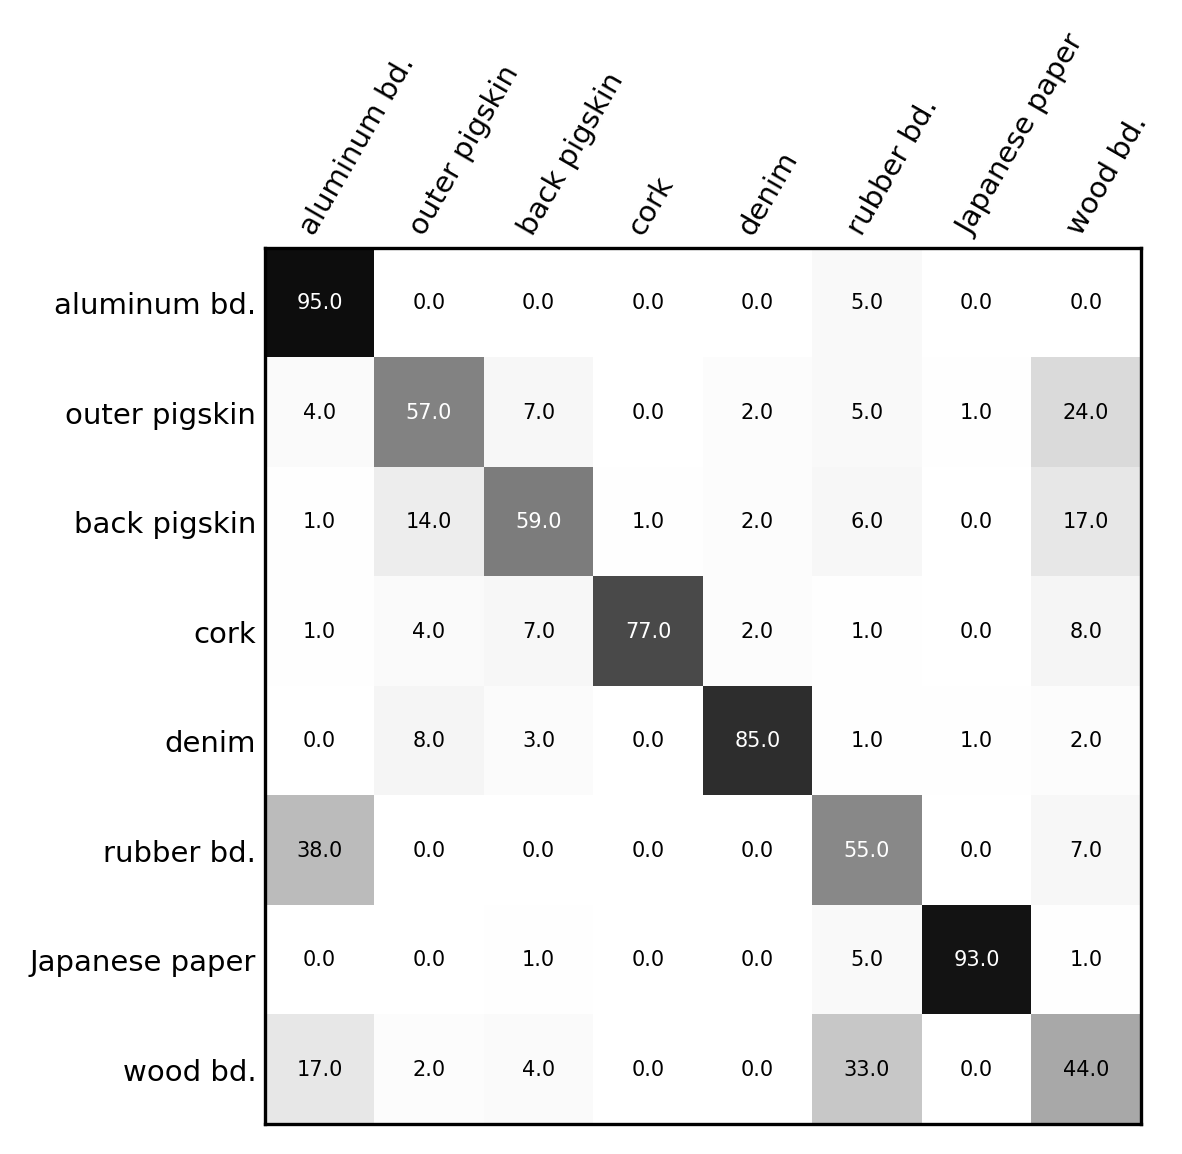

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 入力
# =========================
PROJECT_ROOT = Path(r"C:\Users\haru4\研究\研究コード\code")
XLSX = PROJECT_ROOT / "results_10fold" / "SRDP_1" / "SRDP_1_rep03_Tn_25_10fold_conf_matrices.xlsx"

# =========================
# 保存先
# =========================
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

OUT_DIR = SCRIPT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PDF = OUT_DIR / "conf8cls_icann_bw.pdf"

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["font.size"] = 8

# =========================
# 読み込み
# =========================
df = pd.read_excel(XLSX, sheet_name="conf_8cls", header=None)

raw_names = df.iloc[0, 1:].astype(str).tolist()
cm = df.iloc[1:, 1:].to_numpy(dtype=float)

# =========================
# ラベル自動変換
# =========================
name_map = {
    "Al_board": "aluminum bd.",
    "buta_omote": "outer pigskin",
    "buta_ura": "back pigskin",
    "cork": "cork",
    "denim": "denim",
    "rubber_board": "rubber bd.",
    "washi": "Japanese paper",
    "wood_board": "wood bd."
}

class_names = [name_map.get(x, x) for x in raw_names]

# =========================
# 行正規化
# =========================
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = cm / np.where(row_sums == 0, 1, row_sums)

# =========================
# プロット
# =========================
fig, ax = plt.subplots(figsize=(4.8, 4.0), dpi=300)

im = ax.imshow(cm_norm, cmap="Greys", vmin=0.0, vmax=1.0)

# 軸ラベルは消す
ax.set_xlabel("")
ax.set_ylabel("")

# 目盛り位置
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

# 上側にxラベル
ax.tick_params(
    top=True, bottom=False,
    labeltop=True, labelbottom=False,
    length=0, pad=2
)

ax.set_xticklabels(
    class_names,
    rotation=60,
    ha="left",
    rotation_mode="anchor",
    fontsize=7
)
ax.set_yticklabels(class_names, fontsize=7)

# セル内数値
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        val = cm_norm[i, j]
        ax.text(
            j, i, f"{val*100:.1f}",
            ha="center", va="center",
            color="white" if val >= 0.5 else "black",
            fontsize=5
        )

# 外枠だけ表示
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("black")

fig.subplots_adjust(
    left=0.28,
    right=0.98,
    top=0.78,
    bottom=0.05
)


fig.savefig(OUT_PDF, bbox_inches="tight")

plt.show()
plt.close()

Available learning rules: ['off', 'STDP', 'SRDP', 'T_STDP']
Paired repetitions are matched by the same rep number.


,metric,rule_a,rule_b,n_pairs,mean_a,mean_b,mean_difference_a_minus_b,paired_t_p,wilcoxon_p,paired_t_p_holm,wilcoxon_p_holm
0,accuracy8,off,STDP,10,0.632375,0.475375,0.157000,0.000000,0.001953,0.000000,0.011719
1,accuracy8,off,SRDP,10,0.632375,0.666250,-0.033875,0.042945,0.083984,0.042945,0.083984
2,accuracy8,off,T_STDP,10,0.632375,0.557250,0.075125,0.002763,0.001953,0.007458,0.011719
3,accuracy8,STDP,SRDP,10,0.475375,0.666250,-0.190875,0.000000,0.001953,0.000002,0.011719
4,accuracy8,STDP,T_STDP,10,0.475375,0.557250,-0.081875,0.002486,0.009766,0.007458,0.019531
5,accuracy8,SRDP,T_STDP,10,0.666250,0.557250,0.109000,0.000009,0.001953,0.000036,0.011719
6,accuracy3,off,STDP,10,0.819125,0.743375,0.075750,0.000003,0.001953,0.000013,0.011719
7,accuracy3,off,SRDP,10,0.819125,0.843500,-0.024375,0.008192,0.009766,0.016384,0.029297
8,accuracy3,off,T_STDP,10,0.819125,0.786875,0.032250,0.015447,0.019531,0.016384,0.029297
9,accuracy3,STDP,SRDP,10,0.743375,0.843500,-0.100125,0.000001,0.001953,0.000008,0.011719


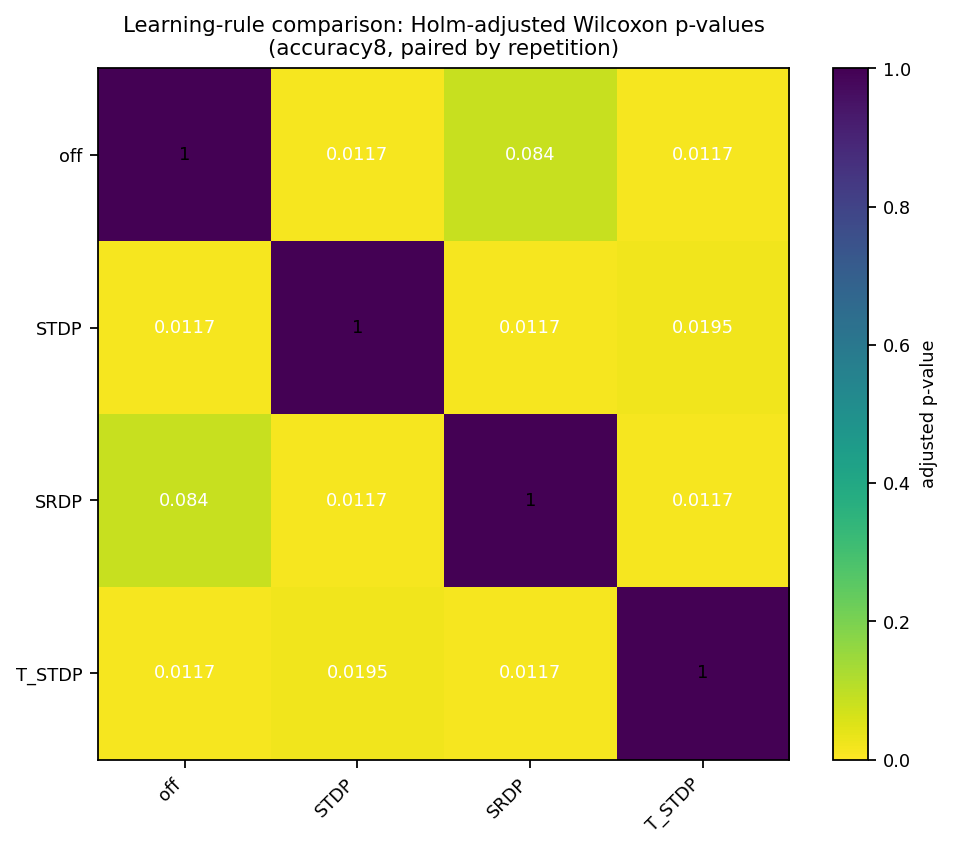

In [9]:
# ============================================================
# Learning-rule comparison: paired p-values across repetitions
# ============================================================
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon

PROJECT_ROOT = Path(r"C:\Users\haru4\研究\研究コード\code")
RESULTS_ROOT = PROJECT_ROOT / "results_10fold"
RULES = {"off": "off_1", "STDP": "STDP_1", "SRDP": "SRDP_1", "T_STDP": "T_STDP_1"}
N_REPS = 10


def _load_rule_scores(rule_name, dataset_name):
    folder = RESULTS_ROOT / dataset_name
    rows = []
    for rep in range(1, N_REPS + 1):
        files = sorted(folder.glob(f"*rep{rep:02d}*10fold_conf_matrices.xlsx"))
        if not files:
            continue
        accuracy = pd.read_excel(files[0], sheet_name="accuracy")
        row = {"rep": rep, "rule": rule_name}
        for metric in ("accuracy8", "accuracy3"):
            column = next((c for c in (f"{metric}_overall", f"{metric}_mean") if c in accuracy.columns), None)
            if column is not None:
                row[metric] = float(accuracy.iloc[0][column])
        rows.append(row)
    return pd.DataFrame(rows)

scores = pd.concat([_load_rule_scores(rule, dataset) for rule, dataset in RULES.items()], ignore_index=True)
available_rules = [r for r in RULES if (scores["rule"] == r).any()]
print("Available learning rules:", available_rules)
print("Paired repetitions are matched by the same rep number.")


def _holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(p_values.shape, np.nan, dtype=float)
    valid = np.isfinite(p_values)
    indices = np.flatnonzero(valid)
    if not len(indices):
        return adjusted
    order = indices[np.argsort(p_values[indices])]
    running = 0.0
    for rank, index in enumerate(order):
        running = max(running, min(1.0, (len(order) - rank) * p_values[index]))
        adjusted[index] = running
    return adjusted

rows = []
for metric in ("accuracy8", "accuracy3"):
    metric_scores = scores.dropna(subset=[metric])
    for rule_a, rule_b in combinations(available_rules, 2):
        a = metric_scores[metric_scores["rule"] == rule_a][["rep", metric]].rename(columns={metric: "a"})
        b = metric_scores[metric_scores["rule"] == rule_b][["rep", metric]].rename(columns={metric: "b"})
        paired = a.merge(b, on="rep", how="inner").sort_values("rep")
        if len(paired) < 2:
            continue
        values_a, values_b = paired["a"].to_numpy(float), paired["b"].to_numpy(float)
        difference = values_a - values_b
        t_p = float(ttest_rel(values_a, values_b).pvalue)
        if np.allclose(difference, 0.0):
            w_p = 1.0
        else:
            try:
                w_p = float(wilcoxon(values_a, values_b, alternative="two-sided").pvalue)
            except ValueError:
                w_p = np.nan
        rows.append({"metric": metric, "rule_a": rule_a, "rule_b": rule_b, "n_pairs": len(paired), "mean_a": values_a.mean(), "mean_b": values_b.mean(), "mean_difference_a_minus_b": difference.mean(), "paired_t_p": t_p, "wilcoxon_p": w_p})

pvalue_table = pd.DataFrame(rows)
if pvalue_table.empty:
    print("No paired result files were found. Run the evaluation for the learning rules first.")
else:
    for column in ("paired_t_p", "wilcoxon_p"):
        pvalue_table[column + "_holm"] = np.nan
        for metric in pvalue_table["metric"].unique():
            mask = pvalue_table["metric"] == metric
            pvalue_table.loc[mask, column + "_holm"] = _holm_adjust(pvalue_table.loc[mask, column].to_numpy())
    display(pvalue_table.round(6))
    output_dir = PROJECT_ROOT / "analysis"
    output_dir.mkdir(parents=True, exist_ok=True)
    pvalue_table.to_csv(output_dir / "learning_rule_pvalues_paired.csv", index=False)
    metric = "accuracy8"
    p_matrix = pd.DataFrame(1.0, index=available_rules, columns=available_rules)
    for _, row in pvalue_table[pvalue_table["metric"] == metric].iterrows():
        p = row["wilcoxon_p_holm"]
        p_matrix.loc[row["rule_a"], row["rule_b"]] = p
        p_matrix.loc[row["rule_b"], row["rule_a"]] = p
    fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=160)
    image = ax.imshow(p_matrix.to_numpy(float), vmin=0.0, vmax=1.0, cmap="viridis_r")
    ax.set_xticks(range(len(available_rules)), available_rules, rotation=45, ha="right")
    ax.set_yticks(range(len(available_rules)), available_rules)
    ax.set_title("Learning-rule comparison: Holm-adjusted Wilcoxon p-values\n(accuracy8, paired by repetition)")
    for i in range(len(available_rules)):
        for j in range(len(available_rules)):
            value = p_matrix.iloc[i, j]
            ax.text(j, i, f"{value:.3g}", ha="center", va="center", color="white" if value < 0.5 else "black")
    fig.colorbar(image, ax=ax, label="adjusted p-value")
    fig.tight_layout()
    fig.savefig(output_dir / "learning_rule_pvalues_accuracy8_heatmap.png", bbox_inches="tight")
    plt.show()

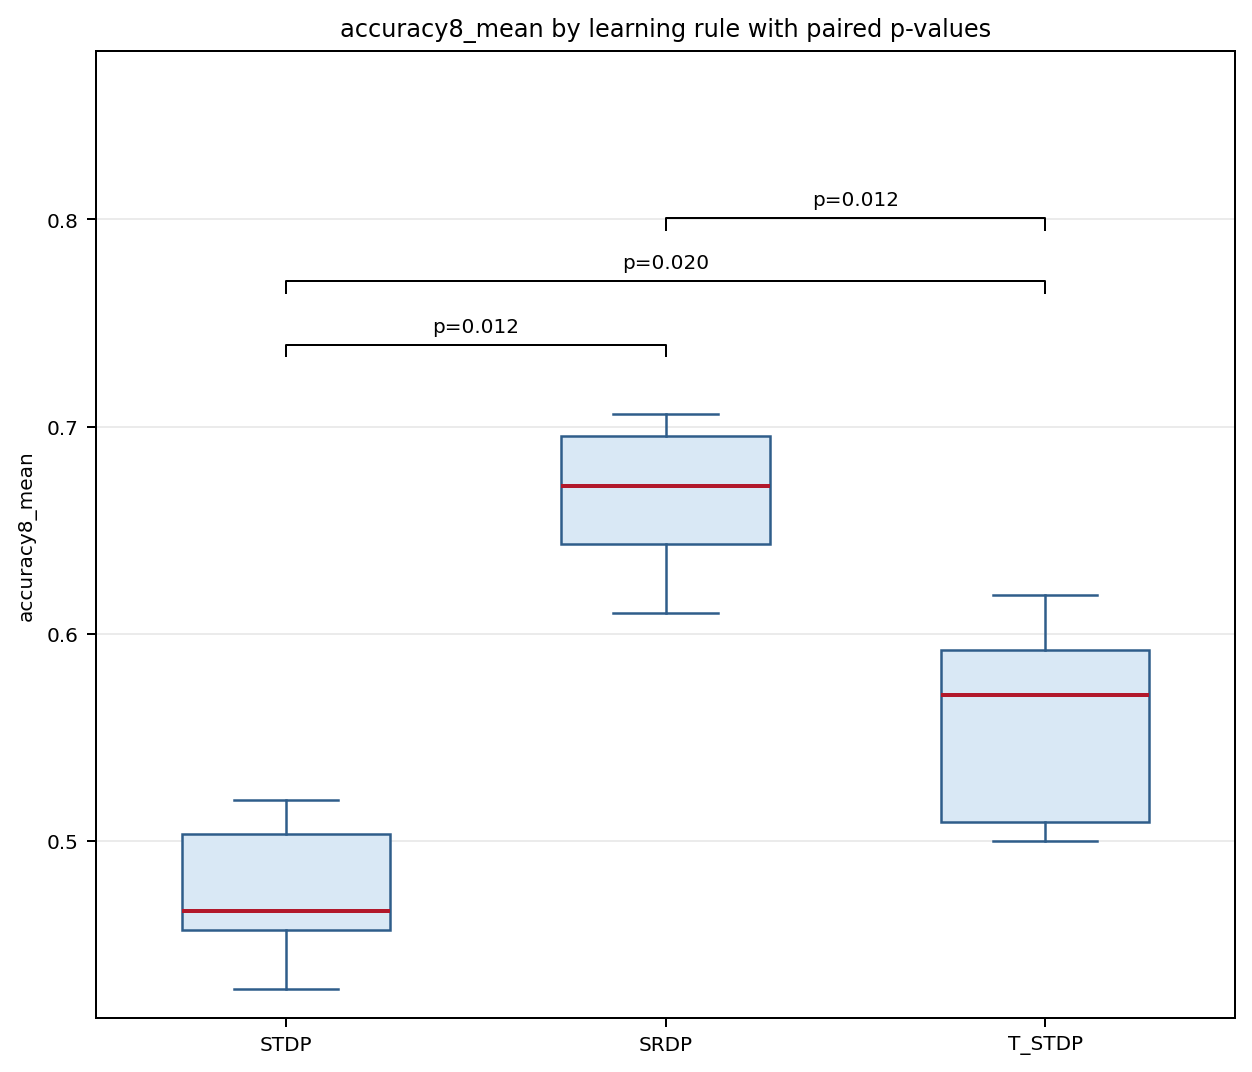

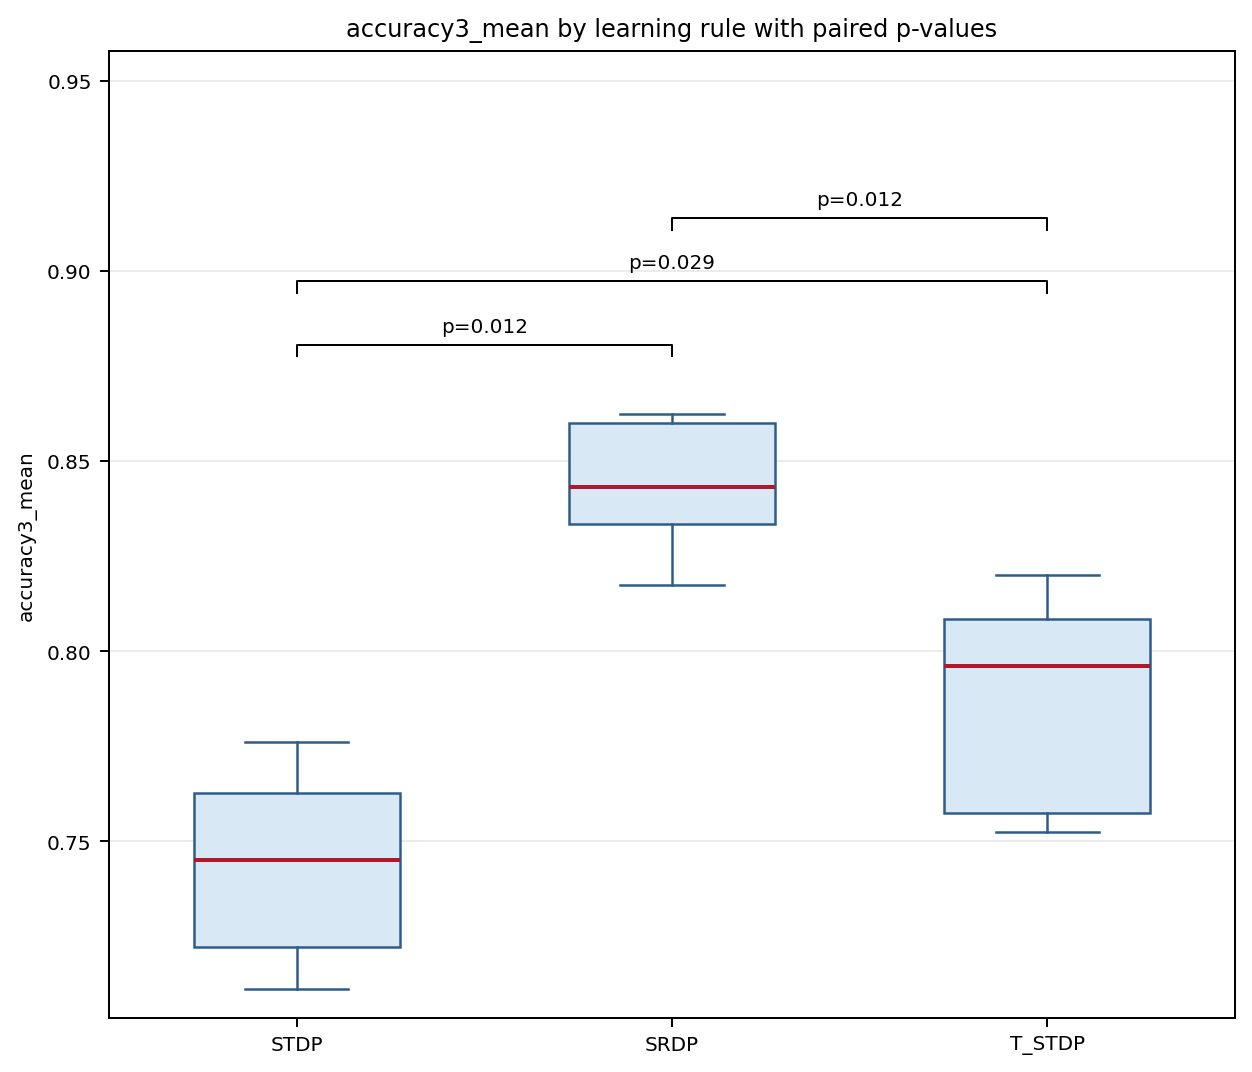

In [10]:
# ============================================================
# Boxplots with paired p-values
# Run the preceding p-value cell first.
# ============================================================
from itertools import combinations
from scipy.stats import wilcoxon


def _p_label(p):
    if not np.isfinite(p):
        return "n/a"
    if p < 0.001:
        return "p<.001"
    return f"p={p:.3f}"


def boxplot_with_pvalues(df, metric, out_path, pvalue_table):
    rule_order = [r for r in RULES if r in set(df["rule"])]
    values = [df.loc[df["rule"] == rule, metric].dropna().to_numpy(float) for rule in rule_order]
    values = [v for v in values if len(v)]
    rule_order = [rule for rule, value in zip(rule_order, values) if len(value)]
    if not values:
        print(f"No data for {metric}")
        return

    fig, ax = plt.subplots(figsize=(max(7, 1.8 * len(rule_order)), 6), dpi=180)
    positions = np.arange(1, len(rule_order) + 1)
    ax.boxplot(values, positions=positions, widths=0.55, patch_artist=True,
               boxprops=dict(facecolor="#d9e8f5", color="#2f5d8a"),
               medianprops=dict(color="#b2182b", linewidth=1.6),
               whiskerprops=dict(color="#2f5d8a"), capprops=dict(color="#2f5d8a"))
    ax.set_xticks(positions, rule_order)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by learning rule with paired p-values")

    pmetric = "accuracy8" if "8" in metric else "accuracy3"
    comparison = pvalue_table[pvalue_table["metric"] == pmetric]
    y_min = min(float(np.min(v)) for v in values)
    y_max = max(float(np.max(v)) for v in values)
    span = max(y_max - y_min, 0.05)
    base = y_max + 0.12 * span
    step = 0.11 * span
    line_index = 0
    for rule_a, rule_b in combinations(rule_order, 2):
        row = comparison[((comparison["rule_a"] == rule_a) & (comparison["rule_b"] == rule_b)) |
                         ((comparison["rule_a"] == rule_b) & (comparison["rule_b"] == rule_a))]
        if row.empty:
            continue
        p = float(row.iloc[0]["wilcoxon_p_holm"])
        x1, x2 = positions[rule_order.index(rule_a)], positions[rule_order.index(rule_b)]
        y = base + line_index * step
        ax.plot([x1, x1, x2, x2], [y - 0.02 * span, y, y, y - 0.02 * span], color="black", linewidth=0.8)
        ax.text((x1 + x2) / 2, y + 0.015 * span, _p_label(p), ha="center", va="bottom", fontsize=8)
        line_index += 1
    ax.set_ylim(y_min - 0.05 * span, base + max(line_index, 1) * step + 0.18 * span)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


if "pvalue_table" not in globals() or pvalue_table.empty:
    print("Run the preceding paired p-value cell before this boxplot cell.")
else:
    boxplot_with_pvalues(dT, METRIC_8, OUT_DIR / f"boxplot_8cls_Tn{TARGET_TN}_{suffix}_with_pvalues.pdf", pvalue_table)
    boxplot_with_pvalues(dT, METRIC_3, OUT_DIR / f"boxplot_3cls_Tn{TARGET_TN}_{suffix}_with_pvalues.pdf", pvalue_table)